In [1]:
import json
import os
import sys
from pathlib import Path
from datetime import datetime
from dotenv import load_dotenv
import traceback
load_dotenv()

%load_ext autoreload
%autoreload 2

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))
# print(f"Root path set to: {root_path}")
from eval_agent.user_agent.graph.user_agent_graph import build_graph 

17030
17030


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/query_decomposer.py:37: LangChainDeprecationWarning: The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.
  self.query_analyzer = LLMChain(llm=llm, prompt=self.prompt_builder, verbose=False)


In [2]:

llm = os.getenv("LLM_MODEL")  # e.g., "gpt-4o"
provider = os.getenv("LLM_PROVIDER")  # e.g., "openai"
memory = True # True if it is the experiment of the agent with memory, False if it is the experiment of the agent without memory
database = os.getenv("EXPERIMENT_NAME")
print(f"Running evaluation for LLM: {llm}, Provider: {provider}, Memory: {memory}, Database: {database}")

# Load the experiment dataset
json_file = f'../dataset_generation/dialogue_dataset/{database}_dialogue_dataset.json'
with open(json_file, 'r', encoding='utf-8') as f:
    experiments = json.load(f)


# Build the evaluation graph with the specified memory and environment
eval_graph = build_graph(text_to_sql_agent_memory=memory, env="tec")

experiment_memory = "memory" if memory else "agent_without_memory"
# Defines the name of the file where the results will be saved
evals_filename = f'{llm}-{experiment_memory}-{database}-eval.json'

# If the file already exists, load the experiments already evaluated
if os.path.exists(evals_filename):
    with open(evals_filename, 'r', encoding='utf-8') as f:
        evals = json.load(f)
else:
    evals = []

# Current template configuration (add details of the template used here)
processed_ids = {exp["experiment_id"] for exp in evals}

# Informations to Graph State
model_version = f"{provider}-{llm}"

experiment_type = f"text2sql_evaluation_{experiment_memory}"


Running evaluation for LLM: gpt-4o, Provider: azure, Memory: True, Database: mondial


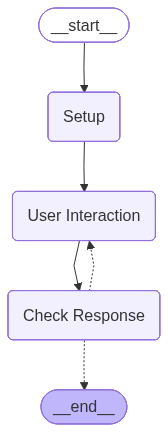

In [3]:
from IPython.display import Image, display


try:
    display(Image(eval_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [ ]:
bird_error_exps = ["6", "14", "24", "33", "34", "43"]
# Iterates over all experiments in the dataset
for experiment in experiments['dataset']:
    exp_id = experiment["experiment_id"]

    if database == "bird":
        
        if exp_id in bird_error_exps:
            continue
    # Se o experimento já foi avaliado, pula para o próximo
    if exp_id in processed_ids:
        print(f"Pulando experimento {exp_id} já processado.")
        continue

    print(f"Processando experimento {exp_id}...")

    try:
        # Invoca a avaliação
        eval_result = eval_graph.invoke(
            {
                "experiment": experiment,
                "max_retries": 2,
                "debug_mode": True,
                "model_version": model_version,
                "experiment_type": experiment_type,
            },
            {"recursion_limit": 200}
        )

        print("Experimento avaliado:\n", eval_result["experiment_eval"])

        # Salva resultado
        evals.append({
            "experiment_id": exp_id,
            "experiment_config": eval_result.get(
                "experiment_config",
                {
                    "max_retries": 2,
                    "model_version": model_version,
                    "timestamp": datetime.now().isoformat(),
                    "experiment_type": experiment_type,
                }
            ),
            "experiment_eval": eval_result["experiment_eval"]
        })

    except Exception as e:
        print(f"\n Erro ao processar experimento {exp_id}: {e}")
        traceback.print_exc()

        # (Opcional) registra falha no arquivo de saída
        # evals.append({
        #     "experiment_id": exp_id,
        #     "experiment_config": {
        #         "model_version": model_version,
        #         "timestamp": datetime.now().isoformat(),
        #         "experiment_type": experiment_type,
        #     },
        #     "experiment_eval": None,
        #     "error": str(e)
        # })

    finally:
        # Atualiza o arquivo SEMPRE (sucesso ou erro)
        with open(evals_filename, 'w', encoding='utf-8') as f:
            json.dump(evals, f, indent=4)

Processando experimento 1...
[NODE] Setup Node entered.
----------------------------------------
[NODE] User Interaction Node entered.
[INFO] Enviando a query para o agente:  What are the names and GMT offsets of all airports?


/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/venv/lib/python3.10/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=4bce5ca5-b091-49cb-a775-3d2da4bd57c8,id=4bce5ca5-b091-49cb-a775-3d2da4bd57c8; trace=4bce5ca5-b091-49cb-a775-3d2da4bd57c8,id=4502b0c7-b95a-44e8-bdfa-d6e58fd274f6; trace=4bce5ca5-b091-49cb-a775-3d2da4bd57c8,id=f1a2ebfd-f89d-4b8a-8721-55b2f3b90d42; trace=4bce5ca5-b091-49cb-a775-3d2da4bd57c8,id=7649cf28-ed99-43f3-9368-bb271cdb5f38; trace=4bce5ca5-b091-49cb-a775-3d2da4bd57c8,id=8373b1f8-6bd5-4e16-9021-18c9bef2c76f; trace=4bce5ca5-b091-49cb-a775-3d2da4bd57c8,id=418f9315-1f88-456c-a1e

Decomposition
['List the names and GMT offsets of all airports.', 'Quais são os nomes de todos os aeroportos?', 'Quais são os GMT offsets de todos os aeroportos?']


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=4bce5ca5-b091-49cb-a775-3d2da4bd57c8,id=1f55b64c-aa98-4904-b58f-b2aa7cd2f8de; trace=4bce5ca5-b091-49cb-a775-3d2da4bd57c8,id=a5117f40-818d-4683-ad2f-1a84c01dcb5a


(17030,)
(17030,)
(17030,)
DFE
Question: What are the different time zone offsets found in the airport information?
SELECT DISTINCT GMTOFFSET 
FROM MONDIAL_AIRPORT

Question: What are the different time zone offsets found in the airport data?
SELECT DISTINCT GMTOFFSET 
FROM MONDIAL_AIRPORT

Question: What are the different time zone offsets in the airport data?
SELECT DISTINCT GMTOFFSET FROM MONDIAL_AIRPORT

Question: different time zone offsets airport information
SELECT DISTINCT GMTOFFSET 
FROM MONDIAL_AIRPORT

Question: Which airports are listed in the database of airport names?
SELECT NAME, IATACODE FROM MONDIAL_AIRPORT

Question: Which airports are listed in the database of airport names?
SELECT NAME, IATACODE FROM MONDIAL_AIRPORT

Question: How many continent names are there for each airport category, where the airport name is available?
SELECT MA.IATACODE, COUNT(MC.NAME)
FROM MONDIAL_AIRPORT MA
JOIN MONDIAL_COUNTRY MC ON MA.COUNTRY = MC.CODE
JOIN MONDIAL_ENCOMPASSES ME ON MC.NAM

...

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id=c4a2b8d5-ddc8-4bd3-92de-63a172c50495; trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id=9c15619e-1bcb-4275-857a-c935832e755d


(17030,)
(17030,)
(17030,)
DFE
Question: What are the names of airports with an elevation of 35.0 meters located in countries with capitals such as Beograd, Wien, Prishtine, Ljubljana, or Roma?
SELECT MONDIAL_AIRPORT.NAME
FROM MONDIAL_AIRPORT
JOIN MONDIAL_COUNTRY ON MONDIAL_AIRPORT.COUNTRY = MONDIAL_COUNTRY.CODE
WHERE MONDIAL_AIRPORT.ELEVATION = 35.0 AND LOWER(MONDIAL_COUNTRY.CAPITAL) IN ('beograd', 'wien', 'prishtine', 'ljubljana', 'roma')

Question: Which airports are situated in countries where people speak German and Slovak, and have elevations of 25.0 and 811.0?
SELECT MA.NAME
FROM MONDIAL_AIRPORT MA
JOIN MONDIAL_COUNTRY MC ON MA.COUNTRY = MC.CODE
JOIN MONDIAL_LANGUAGE ML ON MC.CODE = ML.COUNTRY
WHERE MA.ELEVATION IN (25.0, 811.0) AND ML.NAME IN ('German', 'Slovak')

Question: What are the airports with elevations of 25.0 and 811.0 that are located in countries where German and Slovak are spoken languages according to the MONDIAL database?
SELECT MA.NAME
FROM MONDIAL_AIRPORT MA
JO

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id=23a7238c-0bb9-418e-9b5c-bc36f9c71426; trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id=a70feeca-9510-4e29-9ae0-fda37f529c32
/Users/tomas_lenzi/TecGraf/benchmark_nl_databases_conversational_interfaces/functions/dataset_utils.py:341: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  result_df = pd.read_sql(SQL_query, con=self.db_connection)


KeyboardInterrupt: 

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id=a70feeca-9510-4e29-9ae0-fda37f529c32; trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id=f790f34e-1ca4-4f1f-a693-5dee3e009df4; trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id=f790f34e-1ca4-4f1f-a693-5dee3e009df4; trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id=23a7238c-0bb9-418e-9b5c-bc36f9c71426; trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id=149bf0c0-d4a9-4c06-911b-653f1159b453; trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id=5c5ae077-d1f3-4d76-aebd-82c8d0d32b0d; trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id=3ca36884-84e1-4cec-a040-3bc781e173d0; trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id=59dd1108-afcb-4d15-bb95-13dcb9a0f658; trace=9e22ec69-5f19-42ed-8d44-2234643c22c4,id